In [23]:
from sklearn.datasets import fetch_olivetti_faces

X, y = fetch_olivetti_faces(return_X_y=True)

Original shape: (400, 4096)
PCA shape: (400, 100)


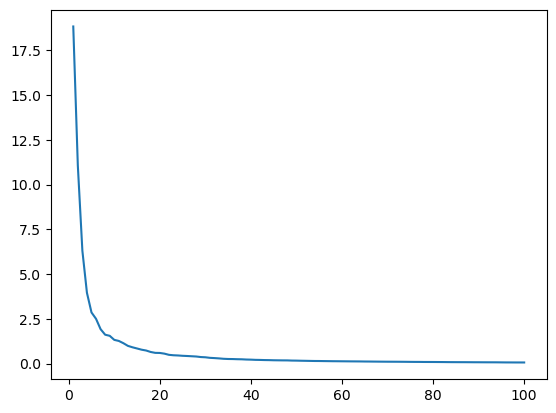

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print(f'Original shape: {X.shape}')

pca = PCA(n_components=100)
X_pca = pca.fit_transform(X)

print(f'PCA shape: {X_pca.shape}')

eigenvalues = pca.explained_variance_

plt.figure()
plt.plot(np.arange(1, len(eigenvalues) + 1), np.sort(eigenvalues)[::-1])
plt.show()

In [25]:
best_n_components = 20
print(f'Best number of components for 95% variance: {best_n_components}')

pca = PCA(n_components=best_n_components)

X_pca = pca.fit_transform(X)

Best number of components for 95% variance: 20


In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB

scores = cross_val_score(GaussianNB(), X_pca, y, cv=StratifiedKFold(n_splits=10, shuffle=True))

print(f'10-fold cross-validated accuracy: {scores.mean():.2g} ± {scores.std():.2g}')

10-fold cross-validated accuracy: 0.93 ± 0.03
